In [0]:
# !pip install pandas
# !pip install polars
# !pip install duckdb

In [0]:
import pandas as pd
import polars as pl
import duckdb
print("Polars version:", pl.__version__)
print("DuckDB version:", duckdb.__version__)

## PROCESAMIENTO CON DATABRICKS

## PROCESAMIENTO REGULAR

### RUTAS DE ORUNCIPALES DE CARPETATAS

In [0]:

# PATH_drive = "/content/drive/MyDrive/PROYECTO MAESTRIA CIENCIA DE DATOS"
# PATH_MOV = f"{PATH_drive}/FILE/MOVIMIENTOS/"
PATH_DATABRICKS = "/Volumes/proyectogrado/source/sourcedb/"
# Carpeta secundaria de los archivos de datos
Archivo_MOVIMIENTOS = f"{PATH_DATABRICKS}LOG_SEGUIMIENTO_ENVIO/LOG_SEGUIMIENTO_ENVIO"
Archivo_GUIAS = f"{PATH_DATABRICKS}LOG_GUIAS/LOG_GUIAS"
Archivo_DOCUMENTOS = f"{PATH_DATABRICKS}/LOG_DOCUMENTOS/LOG_DOCUMENTOS"

# Carpeta secundaria de los archivos parametricos
Archivo_PAR_REGIONALES_PAIS     = f'{PATH_DATABRICKS}PARAMETRICAS/PAR.REGIONALES_PAIS.parquet'
Archivo_PAR_CIUDADES            = f'{PATH_DATABRICKS}PARAMETRICAS/PAR.CIUDADES.parquet'
Archivo_PAR_ESTADOSENVIO        = f'{PATH_DATABRICKS}PARAMETRICAS/PAR.ESTADOSENVIO.parquet'
Archivo_PAR_PROCESOS            = f'{PATH_DATABRICKS}PARAMETRICAS/PAR.PROCESOS.parquet'
Archivo_PAR_ESTADOSGUIA         = f'{PATH_DATABRICKS}PARAMETRICAS/PAR.ESTADOSGUIA.parquet'
Archivo_PAR_ZONASURBANAS        = f'{PATH_DATABRICKS}PARAMETRICAS/PAR.ZONASURBANAS.parquet'
Archivo_DIM_CALENDARIO          = f'{PATH_DATABRICKS}PARAMETRICAS/DIM.VW_TIEMPO_CALENDARIO_Y_FESTIVOS.parquet'
Archivo_PAR_RED_OPERATIVA_OFERTA = f'{PATH_DATABRICKS}PARAMETRICAS/PAR.RED_OPERATIVA_OFERTA.parquet'

### Analisis exploratorio de datos transaccionales

In [0]:
archivos_y_carpetas = dbutils.fs.ls(PATH_DATABRICKS)
# Para imprimir cada elemento:
for elemento in archivos_y_carpetas:
    print(elemento.path)

In [0]:
# Analisis y revision de los datos de las guias
PARQUET_CONSULTA_GUIAS = f"{Archivo_GUIAS}-202601.parquet"
df_resultado = duckdb.sql(f"""
            SELECT  *
            --CAST(NUMERO_GUIA AS BIGINT) AS NUMERO_GUIA
            FROM read_parquet('{PARQUET_CONSULTA_GUIAS}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)

In [0]:
# Analisis y revision de los datos de los movimientos de las guias
PARQUET_CONSULTA_MOVIMIENTOS = f"{Archivo_MOVIMIENTOS}-202601.parquet"
print(PARQUET_CONSULTA_GUIAS)

df_resultado = duckdb.sql(f"""
            SELECT  *
            --CAST(NUMERO_GUIA AS BIGINT) AS NUMERO_GUIA
            FROM read_parquet('{PARQUET_CONSULTA_MOVIMIENTOS}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)

In [0]:
# Analisis y revision de los datos de los docuemntos y manifiestos de las guias
PARQUET_CONSULTA_DOCUMENTOS = f"{Archivo_DOCUMENTOS}-202601.parquet"
print(PARQUET_CONSULTA_GUIAS)

df_resultado = duckdb.sql(f"""
            SELECT  *
            --CAST(NUMERO_GUIA AS BIGINT) AS NUMERO_GUIA
            FROM read_parquet('{PARQUET_CONSULTA_DOCUMENTOS}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)

### Analisis exploratorio de parametricas y dimensiones

In [0]:
parquet_path_CONSULTA_PAR_REGIONALES_PAIS = Archivo_PAR_REGIONALES_PAIS
parquet_path_CONSULTA_PAR_CIUDADES = Archivo_PAR_CIUDADES
parquet_path_CONSULTA_PAR_ESTADOSENVIO = Archivo_PAR_ESTADOSENVIO
parquet_path_CONSULTA_PAR_PROCESOS = Archivo_PAR_PROCESOS
parquet_path_CONSULTA_PAR_ESTADOSGUIA = Archivo_PAR_ESTADOSGUIA
parquet_path_CONSULTA_PAR_ZONASURBANAS = Archivo_PAR_ZONASURBANAS
parquet_path_CONSULTA_DIM_CALENDARIO = Archivo_DIM_CALENDARIO
parquet_path_CONSULTA_PAR_RED_OPERATIVA_OFERTA = Archivo_PAR_RED_OPERATIVA_OFERTA


In [0]:
# Analisis y revision de los datos parametrica RED_OPERATIVA_OFERTA
print(parquet_path_CONSULTA_PAR_RED_OPERATIVA_OFERTA)

df_resultado = duckdb.sql(f"""
            SELECT  *
            --CAST(NUMERO_GUIA AS BIGINT) AS NUMERO_GUIA
            FROM read_parquet('{parquet_path_CONSULTA_PAR_RED_OPERATIVA_OFERTA}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)

In [0]:
# Analisis y revision parametricas de datos REGIONALES_PAIS
df_resultado = duckdb.sql(f"""
            SELECT  *
            FROM read_parquet('{parquet_path_CONSULTA_PAR_REGIONALES_PAIS}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)

In [0]:
# Analisis y revision parametricas de datos CIUDADES
df_resultado = duckdb.sql(f"""
            SELECT  *
            FROM read_parquet('{parquet_path_CONSULTA_PAR_CIUDADES}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)

In [0]:
# Analisis y revision parametricas de datos ESTADOSENVIO
df_resultado = duckdb.sql(f"""
            SELECT  *
            FROM read_parquet('{parquet_path_CONSULTA_PAR_ESTADOSENVIO}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)

In [0]:
# Analisis y revision parametricas de datos PROCESOS
df_resultado = duckdb.sql(f"""
            SELECT  *
            FROM read_parquet('{parquet_path_CONSULTA_PAR_PROCESOS}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)


In [0]:
# Analisis y revision parametricas de datos ESTADOSGUIA
df_resultado = duckdb.sql(f"""
            SELECT  *
            FROM read_parquet('{parquet_path_CONSULTA_PAR_ESTADOSGUIA}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)


In [0]:
# Analisis y revision parametricas de datos ZONASURBANAS
df_resultado = duckdb.sql(f"""
            SELECT  *
            FROM read_parquet('{parquet_path_CONSULTA_PAR_ZONASURBANAS}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)

In [0]:
# Analisis y revision parametricas de datos ESTADOSGUIA
df_resultado = duckdb.sql(f"""
            SELECT  *
            FROM read_parquet('{parquet_path_CONSULTA_DIM_CALENDARIO}')
            LIMIT 5
""").df()
print(columns := df_resultado.columns)
print(df_resultado.dtypes)
display(df_resultado)

In [0]:
df_resultado = duckdb.sql(f"""
    WITH CTE AS (
        SELECT
            CAST(GUI.NUMERO_GUIA AS BIGINT) AS NUMERO_GUIA,
            CIU_DEST.NOMBRE_CIUDAD AS CIUDAD_DESTINO,  -- FIX: el join real es contra ID_CIUDAD_DESTINO, no origen (ver nota en la celda ER)
            PR.NOMBRE_PROCESO_LOG AS NOMBRE_PROCESO,
            REGIO.NOMBRE_REGIONAL AS NOMBRE_REGIONAL,
            ZONA.NOMBRE_ZONA_URBA AS NOMBRE_ZONA_URBANA,
            EST_ENV.NOMBRE_ESTADOENVIO AS NOMBRE_ESTADO_ENVIO,
            EST_GUIA.NOMBRE_ESTADOGUIA AS NOMBRE_ESTADO_GUIA,
            MOV.FECHA_HORA_MOVIMIENTO
        FROM read_parquet('{PARQUET_CONSULTA_GUIAS}') AS GUI
        INNER JOIN read_parquet('{PARQUET_CONSULTA_MOVIMIENTOS}') AS MOV
            ON CAST(MOV.NUMERO_GUIA AS BIGINT) = CAST(GUI.NUMERO_GUIA AS BIGINT)
        INNER JOIN read_parquet('{PARQUET_CONSULTA_DOCUMENTOS}') AS DOC
            ON DOC.ID_PROCESO = MOV.ID_PROCESO
            AND DOC.NUMERO_MOVIMI = MOV.NUMERO_MOVIMI
            AND DOC.CONSECUT_MOVIMI = MOV.CONSECUT_MOVIMI
        INNER JOIN read_parquet('{parquet_path_CONSULTA_PAR_ZONASURBANAS}') AS ZONA
                ON DOC.ID_PAIS_ZONA_URBA = ZONA.ID_PAIS
                AND DOC.ID_CIUDAD_ZONA_URBA = ZONA.ID_CIUDAD
                AND DOC.ID_TIPO_ZONA_URBA = ZONA.ID_TIPO_ZONA_URBA
                AND DOC.ID_ZONA_URBA = ZONA.ID_ZONA_URBA
        LEFT JOIN read_parquet('{parquet_path_CONSULTA_PAR_ESTADOSENVIO}') AS EST_ENV
            ON GUI.ID_ESTADOENVIO = EST_ENV.ID_ESTADOENVIO
        LEFT JOIN read_parquet('{parquet_path_CONSULTA_PAR_ESTADOSGUIA}') AS EST_GUIA
            ON GUI.ID_ESTADOGUIA = EST_GUIA.ID_ESTADOGUIA
        LEFT JOIN read_parquet('{parquet_path_CONSULTA_PAR_CIUDADES}') AS CIU_DEST
            ON GUI.ID_CIUDAD_DESTINO = CIU_DEST.ID_CIUDAD AND GUI.ID_PAIS_DESTINO = CIU_DEST.ID_PAIS
        LEFT JOIN read_parquet('{parquet_path_CONSULTA_PAR_REGIONALES_PAIS}') AS REGIO
            ON REGIO.ID_REGIONAL = CIU_DEST.ID_REGIONAL AND REGIO.ID_EST_REGIONAL = 1
        LEFT JOIN read_parquet('{parquet_path_CONSULTA_PAR_PROCESOS}') AS PR
            ON MOV.ID_PROCESO = PR.ID_PROCESO
        WHERE CIU_DEST.NOMBRE_CIUDAD = 'BOGOTA'
          AND MOV.ID_PROCESO IN (9)
        LIMIT 5
    )
    SELECT * FROM CTE
""").df()

display(df_resultado)

## Diagrama ER del modelo de guías, movimientos y documentos

> Nota (corregida): la consulta original usaba el alias `CIUDAD_ORIGEN`, pero la relación en SQL está hecha sobre `GUI.ID_CIUDAD_DESTINO` y `GUI.ID_PAIS_DESTINO`. Se renombró a `CIUDAD_DESTINO` en la celda de consolidación para que coincida con el modelo lógico real.
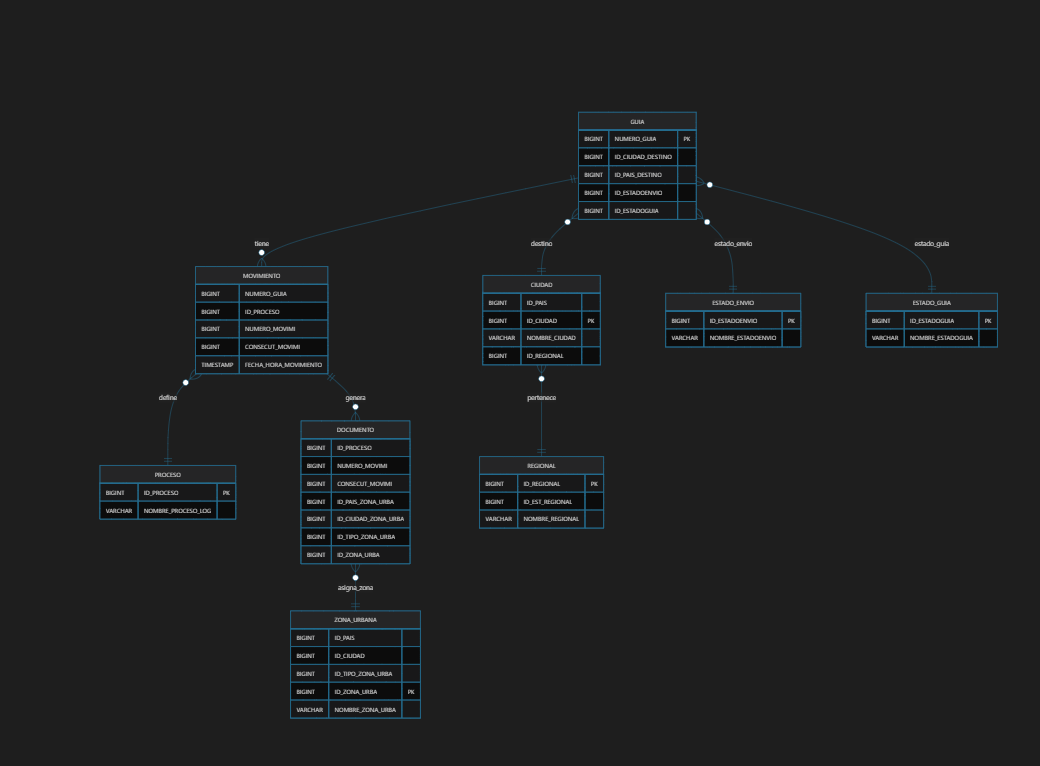
```mermaid
erDiagram
    GUIA {
        BIGINT NUMERO_GUIA PK
        BIGINT ID_CIUDAD_DESTINO
        BIGINT ID_PAIS_DESTINO
        BIGINT ID_ESTADOENVIO
        BIGINT ID_ESTADOGUIA
    }

    MOVIMIENTO {
        BIGINT NUMERO_GUIA
        BIGINT ID_PROCESO
        BIGINT NUMERO_MOVIMI
        BIGINT CONSECUT_MOVIMI
        TIMESTAMP FECHA_HORA_MOVIMIENTO
    }

    DOCUMENTO {
        BIGINT ID_PROCESO
        BIGINT NUMERO_MOVIMI
        BIGINT CONSECUT_MOVIMI
        BIGINT ID_PAIS_ZONA_URBA
        BIGINT ID_CIUDAD_ZONA_URBA
        BIGINT ID_TIPO_ZONA_URBA
        BIGINT ID_ZONA_URBA
    }

    CIUDAD {
        BIGINT ID_PAIS
        BIGINT ID_CIUDAD PK
        VARCHAR NOMBRE_CIUDAD
        BIGINT ID_REGIONAL
    }

    REGIONAL {
        BIGINT ID_REGIONAL PK
        BIGINT ID_EST_REGIONAL
        VARCHAR NOMBRE_REGIONAL
    }

    ESTADO_ENVIO {
        BIGINT ID_ESTADOENVIO PK
        VARCHAR NOMBRE_ESTADOENVIO
    }

    ESTADO_GUIA {
        BIGINT ID_ESTADOGUIA PK
        VARCHAR NOMBRE_ESTADOGUIA
    }

    PROCESO {
        BIGINT ID_PROCESO PK
        VARCHAR NOMBRE_PROCESO_LOG
    }

    ZONA_URBANA {
        BIGINT ID_PAIS
        BIGINT ID_CIUDAD
        BIGINT ID_TIPO_ZONA_URBA
        BIGINT ID_ZONA_URBA PK
        VARCHAR NOMBRE_ZONA_URBA
    }

    GUIA ||--o{ MOVIMIENTO : tiene
    MOVIMIENTO }o--|| PROCESO : define
    MOVIMIENTO ||--o{ DOCUMENTO : genera
    GUIA }o--|| CIUDAD : destino
    CIUDAD }o--|| REGIONAL : pertenece
    GUIA }o--|| ESTADO_ENVIO : estado_envio
    GUIA }o--|| ESTADO_GUIA : estado_guia
    DOCUMENTO }o--|| ZONA_URBANA : asigna_zona
```

### Interpretación de las relaciones
- `GUIA` es la entidad principal. Cada guía tiene uno o varios movimientos.
- `MOVIMIENTO` registra cada cambio de estado o evento de la guía; cada movimiento se asocia a un `PROCESO`.
- `DOCUMENTO` está ligado al movimiento mediante `ID_PROCESO + NUMERO_MOVIMI + CONSECUT_MOVIMI`.
- `ZONA_URBANA` se obtiene desde el documento a través de `ID_PAIS_ZONA_URBA`, `ID_CIUDAD_ZONA_URBA`, `ID_TIPO_ZONA_URBA` y `ID_ZONA_URBA`.
- `CIUDAD` y `REGIONAL` complementan la dimensión geográfica de la guía.
- `ESTADO_ENVIO` y `ESTADO_GUIA` completan los atributos de estado del envío y de la guía.

### Relación de la consulta
La consulta filtrada hace esta lógica:
- `GUIA` ↔ `MOVIMIENTO` por `NUMERO_GUIA`
- `MOVIMIENTO` ↔ `DOCUMENTO` por `ID_PROCESO`, `NUMERO_MOVIMI`, `CONSECUT_MOVIMI`
- `DOCUMENTO` ↔ `ZONA_URBANA` por `ID_PAIS_ZONA_URBA`, `ID_CIUDAD_ZONA_URBA`, `ID_TIPO_ZONA_URBA`, `ID_ZONA_URBA`
- `GUIA` ↔ `CIUDAD` por `ID_CIUDAD_DESTINO` / `ID_PAIS_DESTINO`
- `CIUDAD` ↔ `REGIONAL` por `ID_REGIONAL`
- `GUIA` ↔ `ESTADO_ENVIO` y `ESTADO_GUIA` por sus IDs
- `MOVIMIENTO` ↔ `PROCESO` por `ID_PROCESO`


---

## Etapa 1 (proyecto, sección 4.5.1): Análisis exploratorio y caracterización

Lo que sigue completa lo que pide el proyecto para esta etapa y que el notebook aún no cubría:
la distribución del tiempo de entrega, la tasa global y desagregada de incumplimiento de SLA, los
patrones temporales y espaciales, y las relaciones bivariadas entre las predictoras candidatas y las
dos variables objetivo (`tiempo de entrega`, `incumplimiento de SLA`).

Todo lo de arriba (extracción y revisión tabla por tabla) ya identificaba la estructura de cada fuente;
de aquí en adelante se combinan esas fuentes para caracterizar el fenómeno, que es lo que el
objetivo específico 1 del proyecto pide entregar.

### 1.1 Diagnóstico previo: identificar los campos que definen `tiempo de entrega` e `incumplimiento de SLA`

Antes de calcular nada hace falta confirmar dos cosas que el notebook original no dejaba explícitas:

1. Qué valor(es) de `ID_PROCESO` en `LOG.SEGUIMIENTO_ENVIO` corresponden al evento de **entrega efectiva**
   (la extracción ya filtra `ID_PROCESO IN (5, 6, 9)`, lo que sugiere que la entrega es uno de esos tres,
   pero no hay evidencia en el notebook de cuál).
2. Con qué campo se compara la entrega para saber si hubo **incumplimiento de SLA** (el anteproyecto habla
   de un "tiempo de tránsito comprometido" — sección 4.3.1 — que debe existir en alguna tabla paramétrica
   o derivarse de `ID_ESTADOGUIA`/`ID_ESTADOENVIO`, pero ese campo no apareció en las tablas revisadas arriba).

La celda siguiente imprime el contenido completo (no solo 5 filas) de las tablas paramétricas relevantes
para que este mapeo se pueda hacer a ojo. **Ejecutar esto primero y completar la sección de configuración
(1.2) con los valores reales antes de correr el resto del notebook.**

In [0]:
# Diagnóstico: contenido completo de las tablas que definen procesos y estados
# (a diferencia de las celdas anteriores, aquí no se trunca con LIMIT 5)

df_procesos = duckdb.sql(f"""
    SELECT * FROM read_parquet('{parquet_path_CONSULTA_PAR_PROCESOS}') ORDER BY ID_PROCESO
""").df()
print(f"PAR.PROCESOS ({len(df_procesos)} filas) -- revisar cuál ID_PROCESO representa 'entrega al cliente'")
display(df_procesos)

df_estadosguia = duckdb.sql(f"""
    SELECT * FROM read_parquet('{parquet_path_CONSULTA_PAR_ESTADOSGUIA}') ORDER BY ID_ESTADOGUIA
""").df()
print(f"PAR.ESTADOSGUIA ({len(df_estadosguia)} filas)")
display(df_estadosguia)

df_estadosenvio = duckdb.sql(f"""
    SELECT * FROM read_parquet('{parquet_path_CONSULTA_PAR_ESTADOSENVIO}') ORDER BY ID_ESTADOENVIO
""").df()
print(f"PAR.ESTADOSENVIO ({len(df_estadosenvio)} filas)")
display(df_estadosenvio)

# Estructura completa de GUIAS: buscar cualquier columna que luzca como fecha/tiempo de compromiso
# (p. ej. FECHA_COMPROMISO, DIAS_TRANSITO, FECHA_LIMITE, etc.)
df_guias_schema = duckdb.sql(f"""
    DESCRIBE SELECT * FROM read_parquet('{PARQUET_CONSULTA_GUIAS}')
""").df()
print("Columnas disponibles en LOG.GUIAS:")
display(df_guias_schema)

### 1.2 Configuración: parámetros de negocio que hay que confirmar con el equipo/los datos

Completar estos valores con lo que arroje el diagnóstico anterior. Se dejan explícitos y separados del resto
del código para que quede claro qué es una decisión de negocio (que alguien debe validar) y qué es cálculo.

- `ID_PROCESO_ENTREGA`: el/los `ID_PROCESO` de `LOG.SEGUIMIENTO_ENVIO` que marcan la entrega efectiva del envío.
- `ID_PROCESO_INICIO`: el `ID_PROCESO` (o el uso de `GUI.FECHA_ENVIO`) que marca el inicio del tránsito.
- `CAMPO_SLA_DIAS`: el campo (propio de la guía, de la zona o de una tabla paramétrica de acuerdos) con el
  tiempo de tránsito comprometido. Si no existe como campo explícito, se deja `None` y se documenta como
  limitación (el proyecto ya anticipa esto en 4.10.3: "disponibilidad retrospectiva de variables").


In [0]:
# AJUSTAR estos tres valores según lo observado en la celda de diagnóstico (1.1)
ID_PROCESO_ENTREGA = [9]          # TODO: confirmar contra PAR.PROCESOS (ej. "ENTREGADO A DESTINATARIO")
ID_PROCESO_INICIO = None          # TODO: si hay un ID_PROCESO de "recibido del cliente"; si no, se usa GUI.FECHA_ENVIO
CAMPO_SLA_DIAS = None             # TODO: nombre del campo con el tiempo de tránsito comprometido (días u horas)
SLA_DIAS_DEFAULT = 3              # Valor de referencia solo si CAMPO_SLA_DIAS es None (ajustar con el acuerdo real de SERVIENVIOS)

print("Configuración activa:")
print(f"  ID_PROCESO_ENTREGA = {ID_PROCESO_ENTREGA}")
print(f"  ID_PROCESO_INICIO  = {ID_PROCESO_INICIO}")
print(f"  CAMPO_SLA_DIAS     = {CAMPO_SLA_DIAS}")
print(f"  SLA_DIAS_DEFAULT   = {SLA_DIAS_DEFAULT} (usado solo si no hay CAMPO_SLA_DIAS)")

### 1.3 Construcción de la tabla base de análisis (a nivel de envío)

Une guías + movimientos + parametrías para obtener, por cada `NUMERO_GUIA`, la fecha de inicio, la fecha
de entrega, el `tiempo de entrega` (variable objetivo continua, sección 4.3.1) y el indicador de
`incumplimiento de SLA` (variable objetivo binaria). Se agregan también las dimensiones temporales,
espaciales y de operación que el proyecto lista en la tabla de la sección 4.3.2, para poder cruzarlas
contra las dos variables objetivo más abajo.

Por ahora se usa el periodo `202601` (igual que el resto del notebook) para no procesar todo el histórico en
cada corrida exploratoria; una vez el análisis quede validado, se puede repetir sobre todos los periodos de
`ExtraccionInformacion.ipynb` para construir la base analítica completa de la Etapa 2.

In [0]:
prueba = duckdb.sql(f"""
    SELECT CIU_DEST.NOMBRE_CIUDAD AS CIUDAD_DESTINO
    FROM read_parquet('{parquet_path_CONSULTA_PAR_RED_OPERA}') AS CIU_DEST
""").df()
display(prueba)

In [0]:
df_base = duckdb.sql(f"""
    WITH ENTREGA AS (
        SELECT
            CAST(NUMERO_GUIA AS BIGINT) AS NUMERO_GUIA,
            MIN(FECHA_HORA_MOVIMIENTO) AS FECHA_ENTREGA
        FROM read_parquet('{PARQUET_CONSULTA_GUIAS}') AS GUI
        JOIN read_parquet('{parquet_path_CONSULTA_PAR.RED_OP}') AS RED
        WHERE ID_PROCESO IN ({ids_entrega_sql})
        GROUP BY 1
 """).df()

# Incumplimiento de SLA: variable objetivo binaria (sección 4.3.1)
df_base["INCUMPLIO_SLA"] = (
    df_base["TIEMPO_ENTREGA_HORAS"] > df_base["SLA_DIAS_COMPROMETIDO"] * 24
).astype(int)

print(f"Envíos en la base de análisis: {len(df_base):,}")
display(df_base.head())

### 1.4 Distribución del tiempo de entrega

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df_base["TIEMPO_ENTREGA_HORAS"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_base["TIEMPO_ENTREGA_HORAS"], bins=40, ax=axes[0])
axes[0].set_title("Distribución del tiempo de entrega (horas)")
axes[0].set_xlabel("Horas")

sns.boxplot(x=df_base["TIEMPO_ENTREGA_HORAS"], ax=axes[1])
axes[1].set_title("Tiempo de entrega -- outliers")
axes[1].set_xlabel("Horas")

plt.tight_layout()
plt.show()

# Valores negativos o extremos: candidatos a depurar en la Etapa 2 (criterios de exclusión, sección 4.2.2)
n_negativos = (df_base["TIEMPO_ENTREGA_HORAS"] < 0).sum()
print(f"Registros con tiempo de entrega negativo (dato erróneo, a depurar): {n_negativos}")

### 1.5 Tasa global y desagregada de incumplimiento de SLA

In [0]:
tasa_global = df_base["INCUMPLIO_SLA"].mean()
print(f"Tasa global de incumplimiento de SLA: {tasa_global:.1%}")
print("(el anteproyecto reporta ~20% para el histórico completo de SERVIENVIOS; comparar como control de calidad)")

for col in ["NOMBRE_ZONA_URBANA", "NOMBRE_REGIONAL", "NOMBRE_ESTADO_GUIA"]:
    print(f"\nTasa de incumplimiento por {col}:")
    display(
        df_base.groupby(col)["INCUMPLIO_SLA"]
        .agg(envios="count", tasa_incumplimiento="mean")
        .sort_values("tasa_incumplimiento", ascending=False)
    )

### 1.6 Patrones temporales (hora, día, mes)

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_base.groupby("HORA_SALIDA")["INCUMPLIO_SLA"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Incumplimiento por hora de salida")
axes[0].set_ylabel("Tasa de incumplimiento")

df_base.groupby("DIA_SEMANA")["INCUMPLIO_SLA"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Incumplimiento por día de la semana (0=domingo)")

df_base.groupby("MES")["INCUMPLIO_SLA"].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("Incumplimiento por mes")

plt.tight_layout()
plt.show()

# Tiempo de entrega promedio por hora de salida (para ver si el efecto es sobre el tiempo, el incumplimiento, o ambos)
display(
    df_base.groupby("HORA_SALIDA")["TIEMPO_ENTREGA_HORAS"].mean().round(1).rename("horas_promedio")
)

### 1.7 Patrones espaciales (por zona)

In [0]:
resumen_zona = (
    df_base.groupby("NOMBRE_ZONA_URBANA")
    .agg(
        envios=("NUMERO_GUIA", "count"),
        tiempo_entrega_prom_h=("TIEMPO_ENTREGA_HORAS", "mean"),
        tasa_incumplimiento=("INCUMPLIO_SLA", "mean"),
    )
    .sort_values("tasa_incumplimiento", ascending=False)
)
display(resumen_zona)

top_zonas = resumen_zona.sort_values("envios", ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_zonas.reset_index(), y="NOMBRE_ZONA_URBANA", x="tasa_incumplimiento", ax=ax)
ax.set_title("Tasa de incumplimiento por zona urbana (15 zonas con más envíos)")
plt.tight_layout()
plt.show()

### 1.8 Relaciones bivariadas entre predictoras candidatas y variables objetivo

El proyecto (sección 4.3.2) agrupa las predictoras en cinco dimensiones: temporales, espaciales, de
cliente, de operación y externas/contexto. De las dos primeras ya se vieron patrones arriba; aquí se deja
la matriz de correlación de las variables numéricas disponibles hasta este punto, más un cruce categórico
explícito, como punto de partida. Las variables de cliente, de operación (tipo de vehículo, número de
paradas) y externas (tráfico, clima) todavía no están en el extracto actual -- quedan señaladas como
pendientes para la Etapa 2 (sección 4.5.2 del proyecto), que es donde se integran fuentes externas.

In [0]:
num_cols = ["TIEMPO_ENTREGA_HORAS", "INCUMPLIO_SLA", "HORA_SALIDA", "DIA_SEMANA", "MES"]
corr = df_base[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre variables temporales y las variables objetivo")
plt.tight_layout()
plt.show()

# Cruce categórico: estado de guía vs. incumplimiento (para detectar estados que ya de por sí anticipan el desenlace)
display(
    pd.crosstab(df_base["NOMBRE_ESTADO_GUIA"], df_base["INCUMPLIO_SLA"], normalize="index").round(3)
)

### 1.9 Síntesis -- factores con mayor relación con el retraso (objetivo específico 1)

*(completar esta celda después de correr el notebook con el mapeo real de `ID_PROCESO_ENTREGA` y
`CAMPO_SLA_DIAS`; el propósito es dejar, en dos o tres párrafos, qué zonas, horas o estados concentran el
incumplimiento, para que la Etapa 2 -- ingeniería de características -- sepa qué variables derivadas priorizar,
tal como lo pide la sección 4.5.1 del anteproyecto.)*

**Pendientes que esta etapa deja identificados para la Etapa 2:**
- Confirmar `ID_PROCESO_ENTREGA`, `ID_PROCESO_INICIO` y `CAMPO_SLA_DIAS` con el equipo o con la documentación
  interna de SERVIENVIOS (sección 1.1-1.2 de este notebook).
- Depurar los registros con `TIEMPO_ENTREGA_HORAS` negativo o fuera de rango (criterios de exclusión, 4.2.2).
- Incorporar variables de cliente, operación y externas (tráfico, clima) que aún no están en el extracto,
  para completar las cinco dimensiones de predictoras de la sección 4.3.2.
- Extender el análisis a todo el periodo 2023-2025 una vez validada la lógica sobre el periodo de prueba (202601).